# **4. Binomial Distribution**

## What is the Binomial Distribution?
The **binomial distribution** models the number of successes in a fixed number of independent trials, where each trial has the same probability of success.

## Requirements (BINS)
1. **B**inary outcomes: Each trial has exactly 2 outcomes (success/failure)
2. **I**ndependent trials: One trial doesn't affect another
3. **N** fixed trials: Number of trials is predetermined
4. **S**ame probability: Success probability is constant

## The Formula
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

Where:
- $n$ = number of trials
- $k$ = number of successes
- $p$ = probability of success
- $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ = number of ways to choose k successes

## Parameters
| Parameter | Formula |
|-----------|--------|
| **Mean** | $\mu = np$ |
| **Variance** | $\sigma^2 = np(1-p)$ |
| **Std Dev** | $\sigma = \sqrt{np(1-p)}$ |

In [1]:
# ===============================================
# BINOMIAL DISTRIBUTION: BASICS
# ===============================================

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from math import comb

print("=" * 50)
print("BINOMIAL DISTRIBUTION")
print("=" * 50)

# Example: Flipping a fair coin 10 times
n = 10  # number of trials
p = 0.5  # probability of heads

print(f"\nExample: Flip a fair coin {n} times")
print(f"n = {n}, p = {p}")

# Calculate P(exactly 7 heads)
k = 7

# Manual calculation using formula
ways = comb(n, k)  # Number of ways to get 7 heads
prob_manual = ways * (p**k) * ((1-p)**(n-k))

print(f"\nP(X = {k} heads):")
print(f"  C({n},{k}) × {p}^{k} × {1-p}^{n-k}")
print(f"  = {ways} × {p**k:.6f} × {(1-p)**(n-k):.6f}")
print(f"  = {prob_manual:.4f}")

# Using scipy
prob_scipy = stats.binom.pmf(k, n, p)
print(f"\nUsing scipy: {prob_scipy:.4f}")

BINOMIAL DISTRIBUTION

Example: Flip a fair coin 10 times
n = 10, p = 0.5

P(X = 7 heads):
  C(10,7) × 0.5^7 × 0.5^3
  = 120 × 0.007812 × 0.125000
  = 0.1172

Using scipy: 0.1172


In [2]:
# ===============================================
# BINOMIAL: VARIOUS PROBABILITY CALCULATIONS
# ===============================================

from scipy import stats

n = 10
p = 0.5

print("=" * 50)
print(f"Various Probabilities (n={n}, p={p})")
print("=" * 50)

# P(X = 5)
print(f"\nP(X = 5) = {stats.binom.pmf(5, n, p):.4f}")

# P(X <= 3) - Cumulative
print(f"P(X ≤ 3) = {stats.binom.cdf(3, n, p):.4f}")

# P(X >= 7) = 1 - P(X <= 6)
print(f"P(X ≥ 7) = {1 - stats.binom.cdf(6, n, p):.4f}")

# P(3 <= X <= 7)
print(f"P(3 ≤ X ≤ 7) = {stats.binom.cdf(7, n, p) - stats.binom.cdf(2, n, p):.4f}")

# Mean and standard deviation
mean, var = stats.binom.stats(n, p)
print(f"\nMean (μ) = np = {n}×{p} = {mean}")
print(f"Variance (σ²) = np(1-p) = {n}×{p}×{1-p} = {var}")
print(f"Std Dev (σ) = {np.sqrt(var):.4f}")

Various Probabilities (n=10, p=0.5)

P(X = 5) = 0.2461
P(X ≤ 3) = 0.1719
P(X ≥ 7) = 0.1719
P(3 ≤ X ≤ 7) = 0.8906

Mean (μ) = np = 10×0.5 = 5.0
Variance (σ²) = np(1-p) = 10×0.5×0.5 = 2.5
Std Dev (σ) = 1.5811


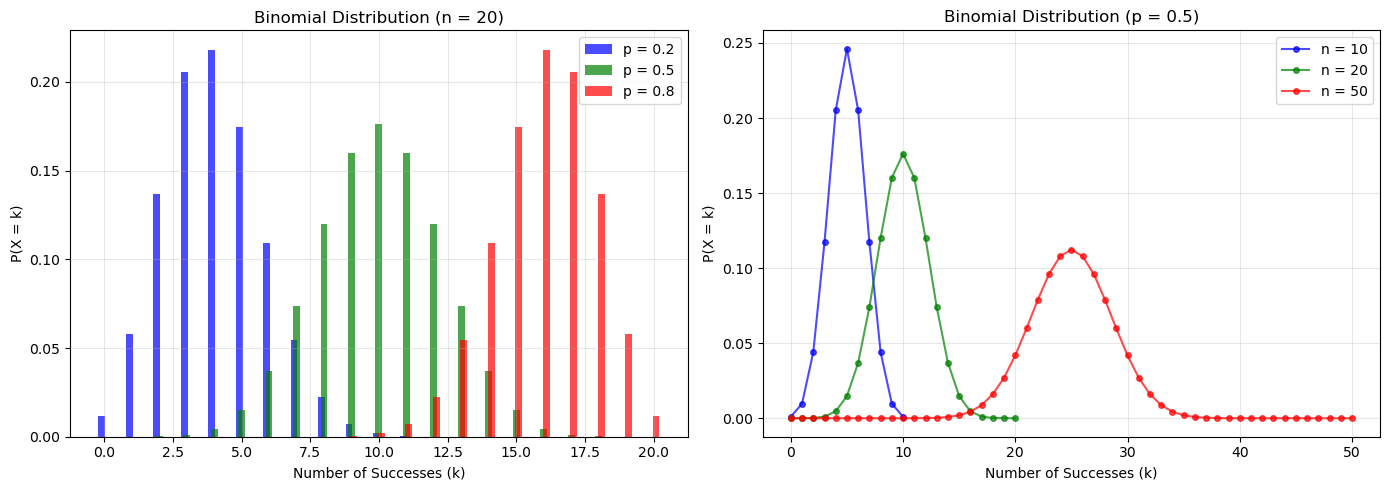

In [3]:
# ===============================================
# VISUALIZING BINOMIAL DISTRIBUTION
# ===============================================

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Different p values (fixed n)
ax1 = axes[0]
n = 20
x = np.arange(0, n+1)

for p, color in [(0.2, 'blue'), (0.5, 'green'), (0.8, 'red')]:
    pmf = stats.binom.pmf(x, n, p)
    ax1.bar(x + (p-0.5)*0.3, pmf, width=0.25, alpha=0.7, 
            color=color, label=f'p = {p}')

ax1.set_xlabel('Number of Successes (k)')
ax1.set_ylabel('P(X = k)')
ax1.set_title(f'Binomial Distribution (n = {n})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Different n values (fixed p)
ax2 = axes[1]
p = 0.5

for n, color in [(10, 'blue'), (20, 'green'), (50, 'red')]:
    x = np.arange(0, n+1)
    pmf = stats.binom.pmf(x, n, p)
    ax2.plot(x, pmf, 'o-', color=color, alpha=0.7, 
             label=f'n = {n}', markersize=4)

ax2.set_xlabel('Number of Successes (k)')
ax2.set_ylabel('P(X = k)')
ax2.set_title(f'Binomial Distribution (p = {p})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

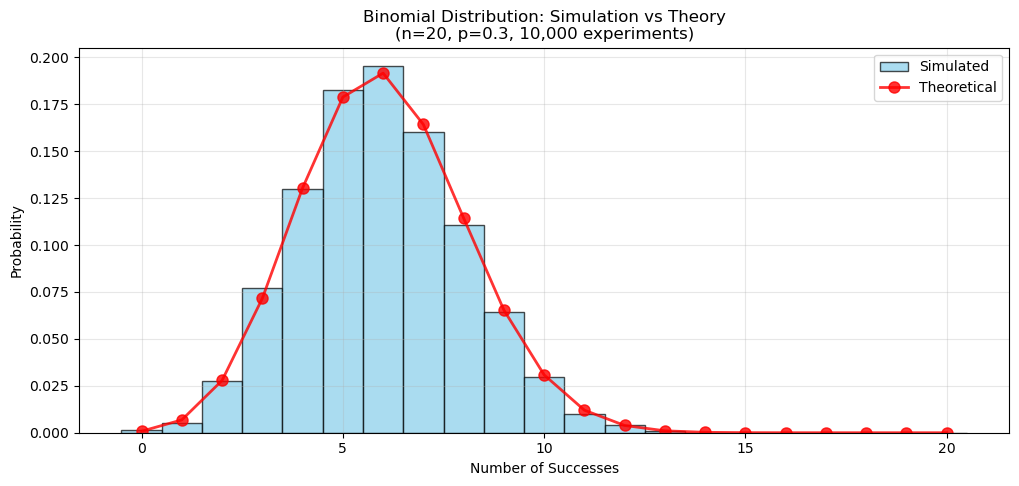


Statistics Comparison:
                      Theoretical    Simulated
Mean:                      6.0000       5.9563
Std Dev:                   2.0494       2.0289


In [4]:
# ===============================================
# BINOMIAL: SIMULATION VS THEORY
# ===============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

n = 20      # trials per experiment
p = 0.3     # success probability
num_experiments = 10000

# Simulate: each experiment flips n coins, count successes
simulated = np.random.binomial(n, p, num_experiments)

# Theoretical probabilities
x = np.arange(0, n+1)
theoretical = stats.binom.pmf(x, n, p)

# Plot comparison
plt.figure(figsize=(12, 5))

# Histogram of simulated data
plt.hist(simulated, bins=np.arange(-0.5, n+1.5, 1), density=True, 
         alpha=0.7, color='skyblue', edgecolor='black', label='Simulated')

# Theoretical PMF
plt.plot(x, theoretical, 'ro-', markersize=8, linewidth=2, 
         label='Theoretical', alpha=0.8)

plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.title(f'Binomial Distribution: Simulation vs Theory\n(n={n}, p={p}, {num_experiments:,} experiments)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Compare statistics
print(f"\nStatistics Comparison:")
print(f"{'':20} {'Theoretical':>12} {'Simulated':>12}")
print(f"{'Mean:':<20} {n*p:>12.4f} {simulated.mean():>12.4f}")
print(f"{'Std Dev:':<20} {np.sqrt(n*p*(1-p)):>12.4f} {simulated.std():>12.4f}")

In [5]:
# ===============================================
# BINOMIAL: DATA SCIENCE APPLICATION
# ===============================================

from scipy import stats

print("=" * 50)
print("APPLICATION: A/B Testing")
print("=" * 50)

# Scenario: Testing a new website button
# Current conversion rate: 5%
# New button shown to 200 visitors: 18 conversions

n = 200
p_baseline = 0.05
observed_conversions = 18

print(f"\nBaseline conversion rate: {p_baseline:.0%}")
print(f"New button: {observed_conversions} conversions out of {n} visitors")
print(f"Observed rate: {observed_conversions/n:.1%}")

# What's the probability of seeing 18 or more conversions by chance?
# Under null hypothesis (no improvement): p = 0.05

p_value = 1 - stats.binom.cdf(observed_conversions - 1, n, p_baseline)

print(f"\n🔍 Statistical Test:")
print(f"P(X ≥ {observed_conversions} | p = {p_baseline}) = {p_value:.4f}")

if p_value < 0.05:
    print(f"\n✅ p-value = {p_value:.4f} < 0.05")
    print("Result is STATISTICALLY SIGNIFICANT!")
    print("The new button likely improves conversions.")
else:
    print(f"\n❌ p-value = {p_value:.4f} >= 0.05")
    print("Result is NOT statistically significant.")
    print("Could be due to random chance.")

APPLICATION: A/B Testing

Baseline conversion rate: 5%
New button: 18 conversions out of 200 visitors
Observed rate: 9.0%

🔍 Statistical Test:
P(X ≥ 18 | p = 0.05) = 0.0121

✅ p-value = 0.0121 < 0.05
Result is STATISTICALLY SIGNIFICANT!
The new button likely improves conversions.


---
## Summary

| Property | Formula/Value |
|----------|---------------|
| **PMF** | $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$ |
| **Mean** | $\mu = np$ |
| **Variance** | $\sigma^2 = np(1-p)$ |
| **SciPy** | `stats.binom.pmf(k, n, p)`, `stats.binom.cdf(k, n, p)` |

### Common Applications
- Quality control (# defective items)
- A/B testing (conversion rates)
- Medical trials (treatment success)
- Customer churn (# customers leaving)